<a href="https://colab.research.google.com/github/leeeshart/Netflix-data-analysis-/blob/main/Netflix_and_movies_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Data Analysis

### By Leesha

This project analyzes Netflix Movies and TV Shows dataset to uncover trends, content distribution, and key insights using Python.

##  Objective

The objective of this project is to analyze Netflix content and answer key questions such as:
- What type of content dominates Netflix (Movies vs TV Shows)?
- Which countries produce the most content?
- How has Netflix content grown over time?
- What are the most popular genres on Netflix?

In [10]:
import pandas as pd

In [11]:
import matplotlib.pyplot as plt

In [12]:
df=pd.read_csv('https://drive.google.com/uc?export=download&id=1r6DwJyOJxr6VKcdPXfwY4Ded8_jdnw8P')

##  Dataset Overview

The dataset contains information about Netflix Movies and TV Shows, including:
- Type (Movie/TV Show)
- Title
- Director and Cast
- Country of production
- Date added to Netflix
- Release year
- Genre (listed_in)

This dataset helps in understanding trends and patterns in Netflix content.

In [13]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [14]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

##  Data Cleaning

In this step, the dataset was prepared for analysis by:
- Filling missing values in columns like country, director, and cast
- Removing duplicate records
- Converting the 'date_added' column to datetime format
- Extracting the year from the date for trend analysis

This ensures that the dataset is clean and ready for accurate analysis.

In [15]:
# check missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [45]:
# fill missing values
df['country'] = df['country'].fillna("Unknown")
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Not Available")

# drop rows where critical data is missing
df = df.dropna(subset=['date_added', 'rating']).copy()

# convert date column
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [31]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

In [32]:
df['type'].value_counts()

,count
type,
Movie,6129
TV Show,2576


In [33]:
df['country'].value_counts().head(10)

,count
country,
United States,2778
India,971
Unknown,826
United Kingdom,403
Japan,240
South Korea,195
Canada,173
Spain,141
France,122


In [34]:
df['year_added'].value_counts().sort_index()

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,10
2014,23
2015,73
2016,417


## What type of content dominates Netflix?

This analysis compares the distribution of Movies and TV Shows available on Netflix.

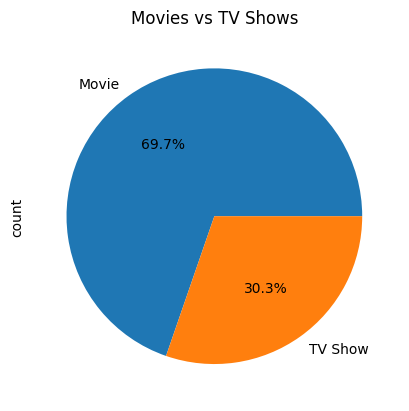

In [17]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Movies vs TV Shows")
plt.show()

In [18]:
# Content type breakdown
type_counts = df['type'].value_counts()
total = len(df)
print(f"Total titles analyzed: {total:,}")
print(f"Movies:   {type_counts['Movie']:,} ({type_counts['Movie']/total*100:.1f}%)")
print(f"TV Shows: {type_counts['TV Show']:,} ({type_counts['TV Show']/total*100:.1f}%)")
print(f"Movie-to-TV ratio: {type_counts['Movie']/type_counts['TV Show']:.1f}:1")

Total titles analyzed: 8,793
Movies:   6,129 (69.7%)
TV Shows: 2,664 (30.3%)
Movie-to-TV ratio: 2.3:1


 Insight:
Movies dominate Netflix content, suggesting the platform focuses more on scalable and widely consumable formats compared to TV Shows.

##  Which countries contribute the most content to Netflix?

This section analyzes the countries contributing the most content to Netflix.

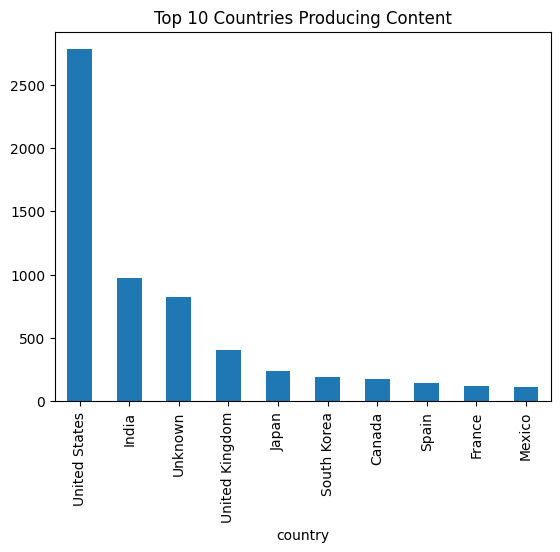

In [35]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries Producing Content")
plt.show()

In [36]:
# Country concentration
country_counts = df['country'].value_counts()
us = country_counts['United States']
india = country_counts['India']
top3 = country_counts.head(3)
known = df[df['country'] != 'Unknown']
print(f"US content:    {us:,} titles ({us/total*100:.1f}%)")
print(f"India content: {india:,} titles ({india/total*100:.1f}%)")
print(f"US + India share: {(us+india)/total*100:.1f}% of all content")
print(f"\nTop 10 countries:")
print(country_counts.head(10))

US content:    2,778 titles (31.6%)
India content: 971 titles (11.0%)
US + India share: 42.6% of all content

Top 10 countries:
country
United States     2778
India              971
Unknown            826
United Kingdom     403
Japan              240
South Korea        195
Canada             173
Spain              141
France             122
Mexico             110
Name: count, dtype: int64


Insight:
The United States is the leading contributor to Netflix content, followed by other countries like India and the United Kingdom.

##  How has Netflix content grown over the years?

This analysis shows the trend of content added to Netflix over time.

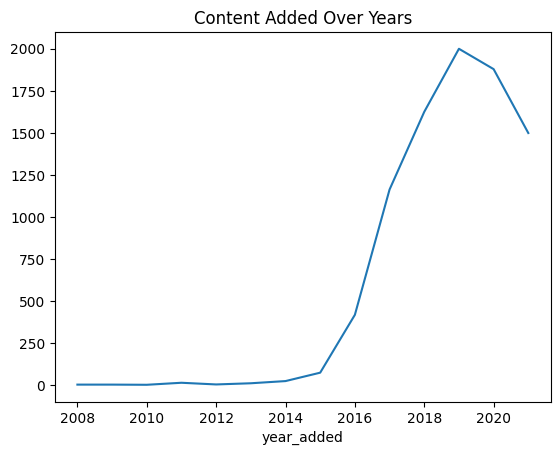

In [37]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added Over Years")
plt.show()

In [42]:
# Growth stats
yearly = df.groupby('year_added')['type'].count().sort_index()
peak_year = yearly.idxmax()
peak_count = yearly.max()
pre_2015 = yearly[yearly.index < 2015].sum()
post_2015 = yearly[yearly.index >= 2015].sum()
print(f"Peak year: {peak_year} with {peak_count:,} titles added")
print(f"Content added before 2015: {pre_2015:,}")
print(f"Content added 2015 onwards: {post_2015:,}")
print(f"Growth multiplier: {post_2015/pre_2015:.1f}x more content after 2015")

Peak year: 2019 with 1,999 titles added
Content added before 2015: 54
Content added 2015 onwards: 8,651
Growth multiplier: 160.2x more content after 2015


Insight:
There is a significant increase in content after 2015, showing Netflix’s rapid expansion in recent years.

##  What are the most popular genres on Netflix?

This section analyzes the most common genres available on Netflix.

In [39]:
# split genres and count them
genre_counts = df['listed_in'].str.split(',').explode().str.strip().value_counts()

# top 10 genres
top_genres = genre_counts.head(10)

top_genres

,count
listed_in,
International Movies,2752
Dramas,2426
Comedies,1674
International TV Shows,1327
Documentaries,869
Action & Adventure,859
Independent Movies,756
TV Dramas,739
Children & Family Movies,641


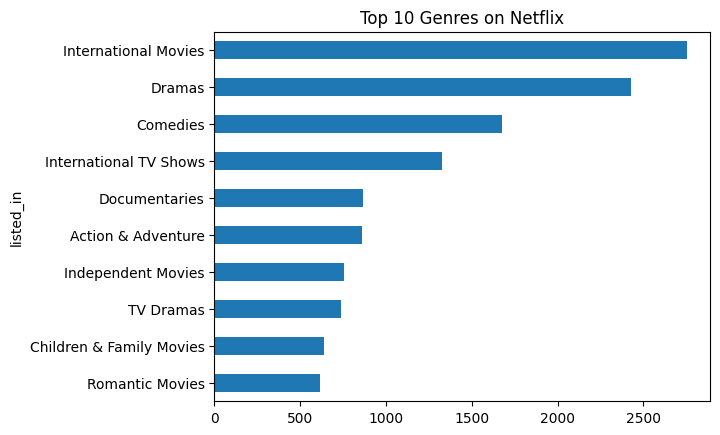

In [40]:
top_genres.sort_values().plot(kind='barh')
plt.title("Top 10 Genres on Netflix")
plt.show()

In [43]:
# Genre breakdown
from collections import Counter
all_genres = df['listed_in'].str.split(', ').explode()
genre_counts = all_genres.value_counts().head(10)
print("Top 10 Genres:")
print(genre_counts)
print(f"\nDrama appears in: {genre_counts.get('Dramas', 0) + genre_counts.get('TV Dramas', 0):,} titles")

Top 10 Genres:
listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1327
Documentaries                869
Action & Adventure           859
Independent Movies           756
TV Dramas                    739
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

Drama appears in: 3,165 titles


Insight:
Drama and Comedy are the most popular genres on Netflix, indicating a strong focus on widely consumed and engaging content.

##  Final Insights

- Movies dominate Netflix content, indicating a stronger focus on widely consumable formats  
- The United States contributes the largest share of content, showing regional concentration  
- Netflix content has grown rapidly after 2015, reflecting aggressive expansion strategies  
- Drama and Comedy are the most popular genres, highlighting audience preference for engaging and relatable content  

##  Conclusion

This analysis reveals that Netflix has strategically expanded its content library over time, with a strong emphasis on movies and popular genres.  

The dominance of content from specific countries and the rapid growth in recent years indicate Netflix’s focus on scalability and global reach.  

Such insights can help understand content trends, user preferences, and business strategies in the streaming industry.